In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../files/train.csv')
test_df = pd.read_csv('../files/test.csv')

datasets = [train_df, test_df]

In [6]:
# columns
train_df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [20]:
# dimension
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
# check if dataset contains missing data

print("Train df\n",train_df.isna().sum())
print("\nTest df\n",test_df.isna().sum())

Train df
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test df
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [31]:
# Identify the unique values of the categorical features (Sex, Embarked)
print(train_df['Sex'].unique())
print(train_df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


In [51]:
# Get the main statistics of numerical features
train_df.describe()
# analisar estes dados tipo media de survived

# train_df.describe(include=['O'])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


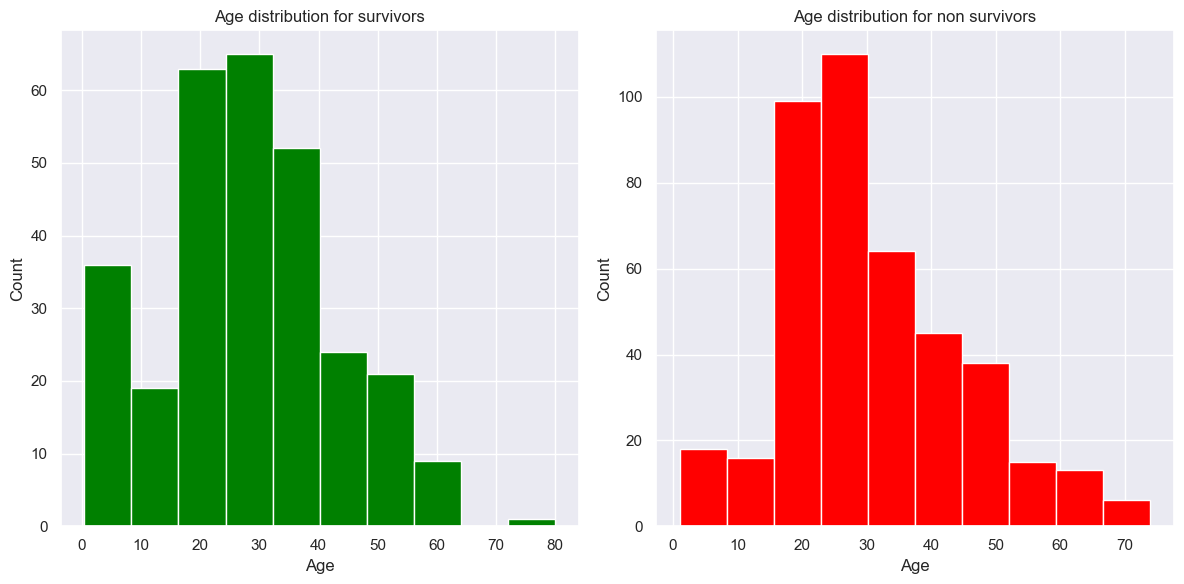

In [202]:
# survivors and non survivors by age
# survived_df = train_df[train_df['Survived'] == 1][['Age']]
# not_survived_df = train_df[train_df['Survived'] == 0][['Age']]
# 
# plt.figure(figsize=(12, 6))
# 
# plt.subplot(1,2,1)
# plt.hist(survived_df['Age'].dropna(), color='green')
# plt.title('Age distribution for survivors')
# plt.xlabel('Age')
# plt.ylabel('Count')
# 
# plt.subplot(1, 2, 2)
# plt.hist(not_survived_df['Age'].dropna(), color='red')
# plt.title('Age distribution for non survivors')
# plt.xlabel('Age')
# plt.ylabel('Count')
# 
# plt.tight_layout()
# plt.show()


# Most passengers are in 15-35 age range.
# Children had high survival rate

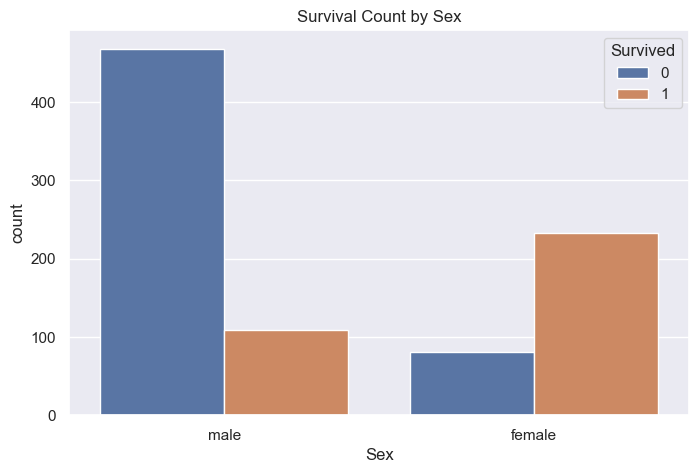

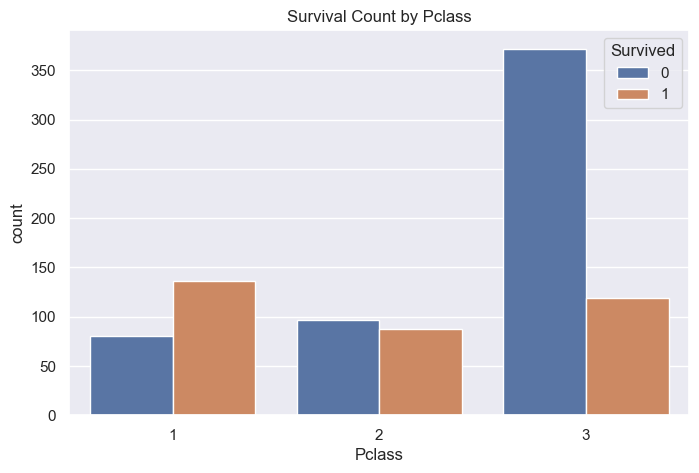

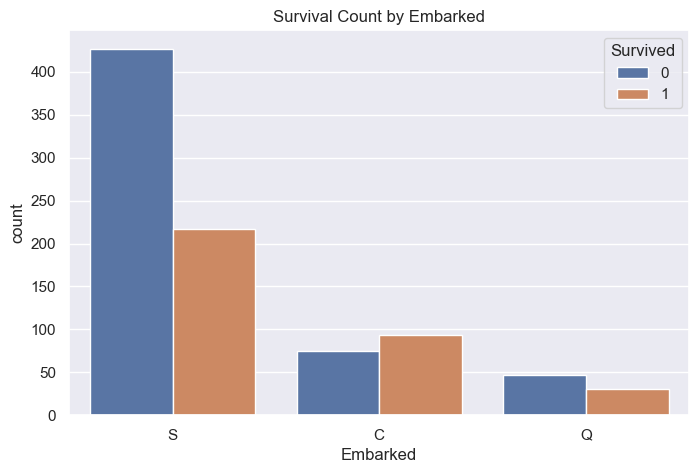

In [198]:
# Create plots for each categorical feature
categorical_features = ['Sex', 'Pclass', 'Embarked']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Survived', data=train_df)
    plt.title('Survival Count by ' + feature)
    plt.show()

# Female passengers had much better survival rate than males.
# Most passengers in Pclass=1 survived
# Port of embarkation may correlate with survival rate

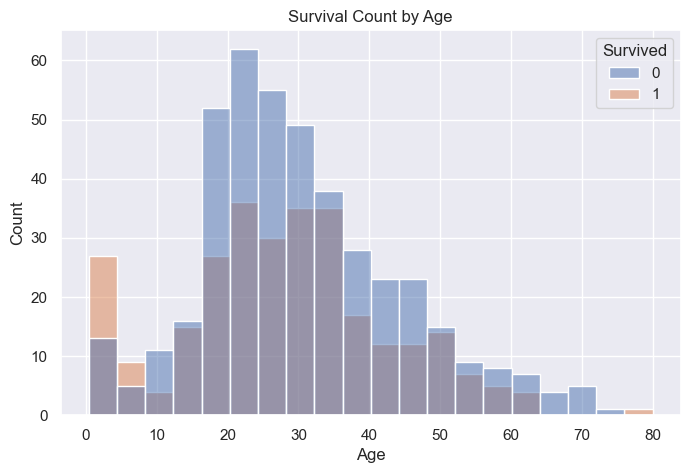

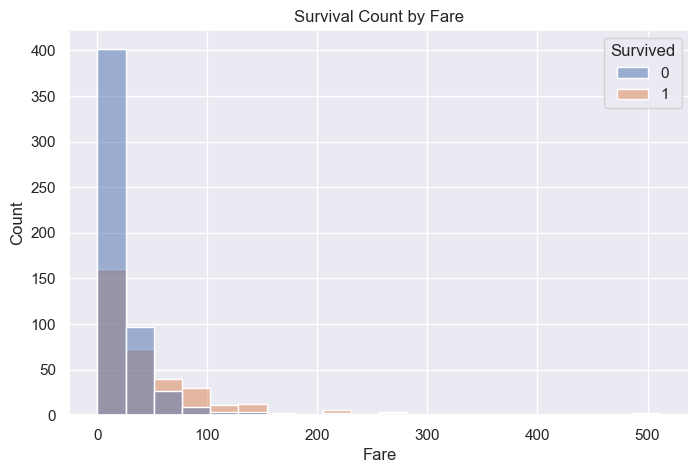

In [211]:
# Create subplots for each numerical feature
numerical_features = ['Age', 'Fare']

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train_df, x=feature, hue='Survived', bins=20)
    plt.title('Survival Count by ' + feature)
    plt.show()


   Pclass     Sex  Survived
0       1  female  0.968085
1       1    male  0.368852
2       2  female  0.921053
3       2    male  0.157407
4       3  female  0.500000
5       3    male  0.135447


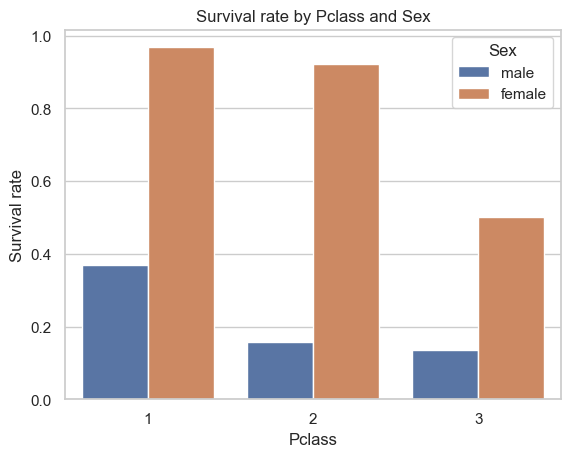

In [27]:
# Survival rate by pclass and sex
survival_rate_by_pclass_and_sex = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
print(survival_rate_by_pclass_and_sex)

sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', errorbar=None)
plt.title("Survival rate by Pclass and Sex")
plt.ylabel("Survival rate")
plt.show()

In [67]:
# drop Cabin and Ticket features on both datasets
# drop PassengerId on training dataset

train_df = train_df.drop(['Ticket', 'Cabin', 'PassengerId'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)

print(train_df.shape, test_df.shape)

(891, 9) (418, 9)


In [ ]:
# extract titles from name feature (sera necessario?)

# for dataset in datasets:
#     dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
# 
# pd.crosstab(train_df['Title'], train_df['Sex'])


In [80]:
# DUMMY ENCODING
# male : 1, female : 0
train_df = pd.get_dummies(data=train_df, columns=['Sex'], drop_first=True)
test_df = pd.get_dummies(data=test_df, columns=['Sex'], drop_first=True)

train_df.rename(columns={'Sex_male' : 'Sex'}, inplace=True)
test_df.rename(columns={'Sex_male' : 'Sex'}, inplace=True)
    
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1
